# 01 — Exploratory Data Analysis: oHCM Cohort & Camzyos Adoption

**IC question:** Who are the oHCM patients in this dataset, who is initiating Camzyos, and what does their symptom profile look like?

This notebook establishes:
1. oHCM cohort identification under two definitions (loose vs. strict)
2. Mavacamten prescription patterns — frequency, persistence, fill gaps
3. Temporal adoption curve
4. Symptom burden among Camzyos patients (dyspnea, HF, fatigue, cardiology E&M)

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["figure.dpi"] = 120

DATA_DIR = Path("../synthetic_data")

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

In [2]:
patients = pd.read_csv(DATA_DIR / "patients.csv")
diagnoses = pd.read_csv(DATA_DIR / "diagnoses.csv", parse_dates=["date"])
procedures = pd.read_csv(DATA_DIR / "procedures.csv", parse_dates=["date"])
prescriptions = pd.read_csv(DATA_DIR / "prescriptions.csv", parse_dates=["date"])
enrollment = pd.read_csv(DATA_DIR / "enrollment.csv")
code_dict = pd.read_csv(DATA_DIR / "code_dictionary.csv")

print(f"Patients:      {len(patients):,}")
print(f"Diagnoses:     {len(diagnoses):,}")
print(f"Procedures:    {len(procedures):,}")
print(f"Prescriptions: {len(prescriptions):,}")
print(f"Enrollment:    {len(enrollment):,}")
print(f"Code dict:     {len(code_dict):,}")

Patients:      30,000
Diagnoses:     3,307,924
Procedures:    1,812,612
Prescriptions: 1,166,961
Enrollment:    1,274,810
Code dict:     775


---
## 1. oHCM Cohort Identification

Two definitions, compared side-by-side:

| Definition | Rule |
|---|---|
| **Loose** | ≥1 claim with ICD-10 I42.1 |
| **Strict** | (≥2 claims with I42.1, ≥30 days apart) OR (≥1 I42.2 + ≥1 I42.1) |

The strict definition reduces false positives from rule-out diagnoses or coding errors.

In [3]:
# --- Loose definition: >= 1 I421 claim ---
ohcm_dx = diagnoses[diagnoses["dx_code"] == "I421"].copy()
cohort_loose = set(ohcm_dx["patient_id"].unique())
print(f"Loose cohort (≥1 I421 claim): {len(cohort_loose):,} patients")

Loose cohort (≥1 I421 claim): 2,506 patients


In [4]:
# --- Strict definition ---
# Path A: ≥2 I421 claims, ≥30 days apart
i421_claims = ohcm_dx.sort_values(["patient_id", "date"])
i421_claims["prev_date"] = i421_claims.groupby("patient_id")["date"].shift(1)
i421_claims["days_gap"] = (i421_claims["date"] - i421_claims["prev_date"]).dt.days

path_a = set(i421_claims.loc[i421_claims["days_gap"] >= 30, "patient_id"].unique())
print(f"Path A (≥2 I421, ≥30d apart): {len(path_a):,} patients")

# Path B: ≥1 I422 AND ≥1 I421
has_i422 = set(diagnoses.loc[diagnoses["dx_code"] == "I422", "patient_id"].unique())
has_i421 = cohort_loose
path_b = has_i422 & has_i421
print(f"Path B (I422 + I421):          {len(path_b):,} patients")

cohort_strict = path_a | path_b
print(f"\nStrict cohort (A ∪ B):         {len(cohort_strict):,} patients")
print(f"Loose − Strict (dropped):      {len(cohort_loose - cohort_strict):,} patients")

Path A (≥2 I421, ≥30d apart): 1,919 patients


Path B (I422 + I421):          1,675 patients

Strict cohort (A ∪ B):         1,969 patients
Loose − Strict (dropped):      537 patients


In [5]:
# --- How many Camzyos patients does each definition capture? ---
mav_patients = set(
    prescriptions.loc[prescriptions["rx_code"] == "Mavacamten", "patient_id"].unique()
)
print(f"Total Mavacamten patients: {len(mav_patients)}")
print(f"  In loose cohort:  {len(mav_patients & cohort_loose)} / {len(mav_patients)}")
print(f"  In strict cohort: {len(mav_patients & cohort_strict)} / {len(mav_patients)}")
print(f"  Neither:          {len(mav_patients - cohort_loose)} (may have I422/I429 only)")

# What dx codes do Camzyos patients outside loose cohort have?
mav_no_i421 = mav_patients - cohort_loose
if mav_no_i421:
    outside_dx = (
        diagnoses[diagnoses["patient_id"].isin(mav_no_i421)]
        .merge(code_dict, left_on="dx_code", right_on="code", how="left")
        .query("dx_code.str.startswith('I42')")[["dx_code", "description"]]
        .drop_duplicates()
    )
    print(f"\nCardiomyopathy codes for {len(mav_no_i421)} Camzyos patients without I421:")
    display(outside_dx)

Total Mavacamten patients: 166
  In loose cohort:  150 / 166
  In strict cohort: 150 / 166
  Neither:          16 (may have I422/I429 only)

Cardiomyopathy codes for 16 Camzyos patients without I421:


,dx_code,description
4,I422,Other Hypertrophic Cardiomyopathy
31,I429,"Cardiomyopathy, Unspecified"
266,I420,Dilated Cardiomyopathy
278,I428,Other Cardiomyopathies


In [6]:
# --- Demographics comparison: loose vs strict ---
def cohort_summary(patient_ids, label):
    df = patients[patients["patient_id"].isin(patient_ids)].copy()
    df["age_2022"] = 2022 - df["birth_year"]
    return pd.Series(
        {
            "label": label,
            "n": len(df),
            "age_median": df["age_2022"].median(),
            "age_q25": df["age_2022"].quantile(0.25),
            "age_q75": df["age_2022"].quantile(0.75),
            "pct_female": (df["sex"] == "F").mean() * 100,
        }
    )


summary = pd.DataFrame(
    [
        cohort_summary(cohort_loose, "Loose (≥1 I421)"),
        cohort_summary(cohort_strict, "Strict (≥2 I421 30d+ OR I422+I421)"),
        cohort_summary(mav_patients, "Mavacamten patients"),
        cohort_summary(cohort_loose - mav_patients, "Loose, no Mavacamten"),
    ]
).set_index("label")

print("Cohort demographics (age as of 2022):")
display(summary)

Cohort demographics (age as of 2022):


,n,age_median,age_q25,age_q75,pct_female
label,,,,,
Loose (≥1 I421),2506,70.0,57.00,79.0,52.154828
Strict (≥2 I421 30d+ OR I422+I421),1969,69.0,56.00,79.0,53.529711
Mavacamten patients,166,70.0,57.25,79.0,56.024096
"Loose, no Mavacamten",2356,70.0,57.00,79.0,51.952462


---
## 2. Mavacamten Prescription Patterns

For each Camzyos patient: how many fills, what supply (30d vs 90d), and are there gaps suggesting discontinuation?

In [7]:
mav_rx = prescriptions[prescriptions["rx_code"] == "Mavacamten"].copy()
mav_rx = mav_rx.sort_values(["patient_id", "date"])

print(f"Total Mavacamten fills: {len(mav_rx):,}")
print(f"Unique patients:       {mav_rx['patient_id'].nunique()}")
print("\nDays supply distribution:")
print(mav_rx["days_supply"].value_counts().to_string())

Total Mavacamten fills: 1,472
Unique patients:       166

Days supply distribution:
days_supply
30    1142
90     330


Fills per patient:


,count,mean,std,min,25%,50%,75%,max
n_fills,166.0,8.86747,4.607691,1.0,5.0,9.0,13.0,18.0


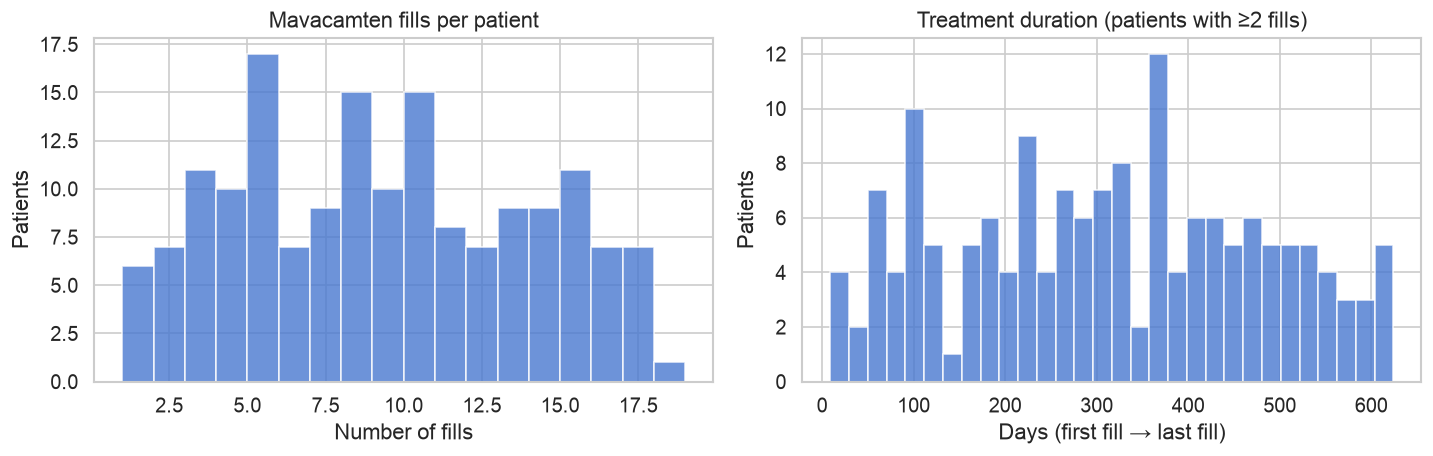

In [8]:
# --- Per-patient fill summary ---
mav_per_patient = (
    mav_rx.groupby("patient_id")
    .agg(
        n_fills=("date", "count"),
        first_fill=("date", "min"),
        last_fill=("date", "max"),
        pct_90d=("days_supply", lambda x: (x == 90).mean() * 100),
    )
    .reset_index()
)
mav_per_patient["duration_days"] = (
    mav_per_patient["last_fill"] - mav_per_patient["first_fill"]
).dt.days

print("Fills per patient:")
display(mav_per_patient["n_fills"].describe().to_frame().T)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(
    mav_per_patient["n_fills"],
    bins=range(1, mav_per_patient["n_fills"].max() + 2),
    edgecolor="white",
    alpha=0.8,
)
axes[0].set_xlabel("Number of fills")
axes[0].set_ylabel("Patients")
axes[0].set_title("Mavacamten fills per patient")

axes[1].hist(
    mav_per_patient.loc[mav_per_patient["duration_days"] > 0, "duration_days"],
    bins=30,
    edgecolor="white",
    alpha=0.8,
)
axes[1].set_xlabel("Days (first fill → last fill)")
axes[1].set_ylabel("Patients")
axes[1].set_title("Treatment duration (patients with ≥2 fills)")

plt.tight_layout()
plt.show()

---
## 3. Mavacamten Prescriptions Over Time

Two views:
- **New initiations per month** (first fill per patient) — the actual adoption signal
- **Total fills per month** — confounds new starts with persistence/refills

In [9]:
mav_rx["year_month"] = mav_rx["date"].dt.to_period("M")

# Total fills per month
total_fills = mav_rx.groupby("year_month").size().rename("total_fills")

# New initiations per month (first fill per patient)
first_fills = mav_rx.groupby("patient_id")["date"].min().reset_index()
first_fills["year_month"] = first_fills["date"].dt.to_period("M")
new_starts = first_fills.groupby("year_month").size().rename("new_initiations")

# Cumulative initiations
cumulative = new_starts.cumsum().rename("cumulative_patients")

monthly = pd.concat([total_fills, new_starts, cumulative], axis=1).fillna(0).astype(int)
print("Monthly Mavacamten summary:")
display(monthly)

Monthly Mavacamten summary:


,total_fills,new_initiations,cumulative_patients
year_month,,,
2022-04,7,7,7
2022-05,14,10,17
2022-06,16,6,23
2022-07,25,7,30
2022-08,34,10,40
2022-09,41,9,49
2022-10,52,10,59
2022-11,50,5,64
2022-12,67,18,82


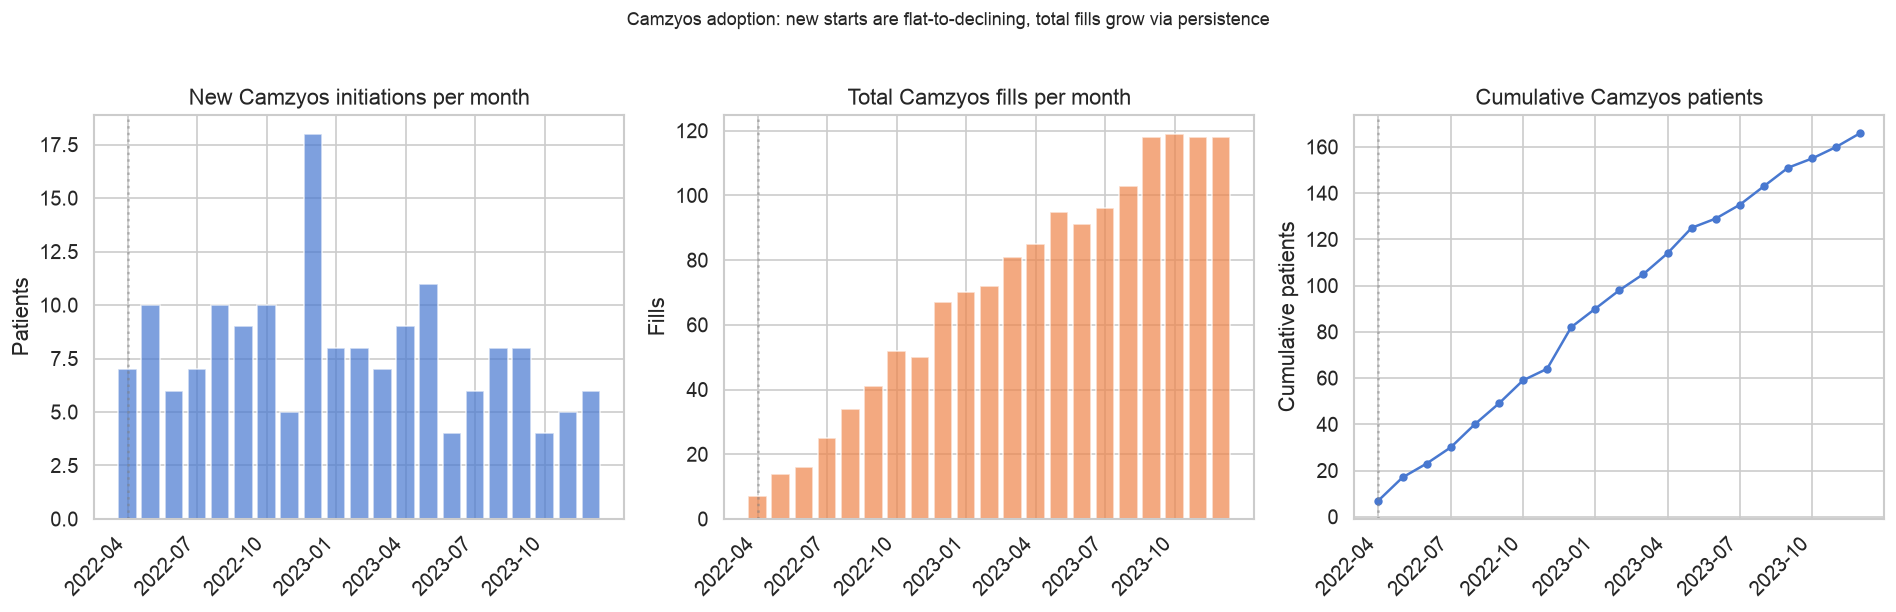

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# New initiations
x = range(len(monthly))
labels = [str(p) for p in monthly.index]

axes[0].bar(x, monthly["new_initiations"], alpha=0.7, edgecolor="white")
axes[0].set_xticks(x[::3])
axes[0].set_xticklabels(labels[::3], rotation=45, ha="right")
axes[0].set_ylabel("Patients")
axes[0].set_title("New Camzyos initiations per month")

# Total fills
axes[1].bar(x, monthly["total_fills"], alpha=0.7, color="C1", edgecolor="white")
axes[1].set_xticks(x[::3])
axes[1].set_xticklabels(labels[::3], rotation=45, ha="right")
axes[1].set_ylabel("Fills")
axes[1].set_title("Total Camzyos fills per month")

# Cumulative
axes[2].plot(x, monthly["cumulative_patients"], marker="o", markersize=4)
axes[2].set_xticks(x[::3])
axes[2].set_xticklabels(labels[::3], rotation=45, ha="right")
axes[2].set_ylabel("Cumulative patients")
axes[2].set_title("Cumulative Camzyos patients")

for ax in axes:
    ax.axvline(x=0, color="grey", linestyle=":", alpha=0.5)

fig.suptitle(
    "Camzyos adoption: new starts are flat-to-declining, total fills grow via persistence",
    fontsize=11,
    y=1.02,
)
plt.tight_layout()
plt.show()

---
## 4. Symptom Burden Among Camzyos Patients

We proxy NYHA II/III symptom severity using claims codes:

| Symptom proxy | ICD-10 codes |
|---|---|
| Dyspnea | R0600, R0602, R0609 |
| Heart failure | I50xx (all) |
| Fatigue | R5383, R531, R5381 |
| Cardiology E&M (high complexity) | 99214, 99215, 99204, 99205 |

In [11]:
DYSPNEA_CODES = ["R0600", "R0602", "R0609"]
HF_CODES = [c for c in diagnoses["dx_code"].unique() if str(c).startswith("I50")]
FATIGUE_CODES = ["R5383", "R531", "R5381"]
CARDIO_EM_CODES = ["99214", "99215", "99204", "99205"]

print(f"HF codes in data: {sorted(HF_CODES)}")
print(f"Dyspnea codes:    {DYSPNEA_CODES}")
print(f"Fatigue codes:    {FATIGUE_CODES}")
print(f"Cardio E&M codes: {CARDIO_EM_CODES}")

HF codes in data: ['I5020', 'I5021', 'I5022', 'I5023', 'I5030', 'I5032', 'I5033', 'I5042', 'I509']
Dyspnea codes:    ['R0600', 'R0602', 'R0609']
Fatigue codes:    ['R5383', 'R531', 'R5381']
Cardio E&M codes: ['99214', '99215', '99204', '99205']


In [12]:
def symptom_prevalence(patient_ids, label):
    """Compute symptom prevalence for a set of patients."""
    dx_sub = diagnoses[diagnoses["patient_id"].isin(patient_ids)]
    px_sub = procedures[procedures["patient_id"].isin(patient_ids)]
    n = len(patient_ids)

    has_dyspnea = dx_sub[dx_sub["dx_code"].isin(DYSPNEA_CODES)]["patient_id"].nunique()
    has_hf = dx_sub[dx_sub["dx_code"].isin(HF_CODES)]["patient_id"].nunique()
    has_fatigue = dx_sub[dx_sub["dx_code"].isin(FATIGUE_CODES)]["patient_id"].nunique()
    has_cardio_em = px_sub[px_sub["px_code"].isin(CARDIO_EM_CODES)]["patient_id"].nunique()

    return pd.Series(
        {
            "group": label,
            "n": n,
            "dyspnea_n": has_dyspnea,
            "dyspnea_pct": has_dyspnea / n * 100,
            "hf_n": has_hf,
            "hf_pct": has_hf / n * 100,
            "fatigue_n": has_fatigue,
            "fatigue_pct": has_fatigue / n * 100,
            "cardio_em_n": has_cardio_em,
            "cardio_em_pct": has_cardio_em / n * 100,
            "any_symptom_n": len(
                set(
                    dx_sub[dx_sub["dx_code"].isin(DYSPNEA_CODES + HF_CODES + FATIGUE_CODES)][
                        "patient_id"
                    ].unique()
                )
                | set(px_sub[px_sub["px_code"].isin(CARDIO_EM_CODES)]["patient_id"].unique())
            ),
            "any_symptom_pct": len(
                set(
                    dx_sub[dx_sub["dx_code"].isin(DYSPNEA_CODES + HF_CODES + FATIGUE_CODES)][
                        "patient_id"
                    ].unique()
                )
                | set(px_sub[px_sub["px_code"].isin(CARDIO_EM_CODES)]["patient_id"].unique())
            )
            / n
            * 100,
        }
    )


symptom_df = pd.DataFrame(
    [
        symptom_prevalence(mav_patients, "Camzyos patients"),
        symptom_prevalence(cohort_loose - mav_patients, "oHCM (loose), no Camzyos"),
        symptom_prevalence(cohort_strict - mav_patients, "oHCM (strict), no Camzyos"),
    ]
).set_index("group")

print("Symptom prevalence (ever, across full observation period):")
display(symptom_df.round(1))

Symptom prevalence (ever, across full observation period):


,n,dyspnea_n,dyspnea_pct,hf_n,hf_pct,fatigue_n,fatigue_pct,cardio_em_n,cardio_em_pct,any_symptom_n,any_symptom_pct
group,,,,,,,,,,,
Camzyos patients,166,128,77.1,128,77.1,68,41.0,162,97.6,166,100.0
"oHCM (loose), no Camzyos",2356,1688,71.6,1856,78.8,1025,43.5,2223,94.4,2345,99.5
"oHCM (strict), no Camzyos",1819,1261,69.3,1374,75.5,722,39.7,1716,94.3,1808,99.4


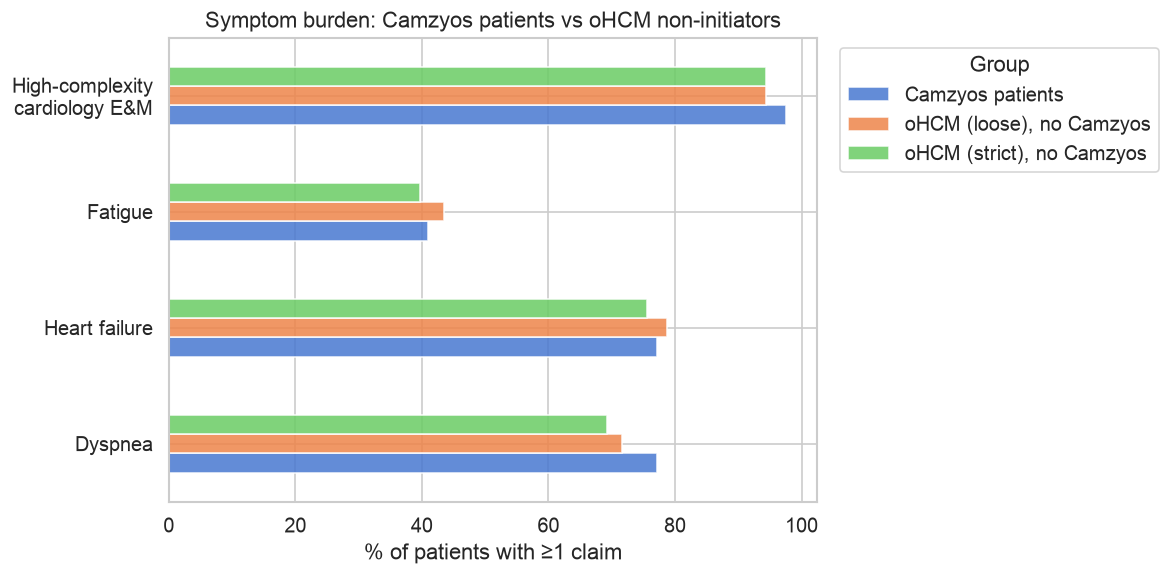

In [13]:
# --- Side-by-side symptom prevalence ---
pct_cols = ["dyspnea_pct", "hf_pct", "fatigue_pct", "cardio_em_pct"]
labels_nice = ["Dyspnea", "Heart failure", "Fatigue", "High-complexity\ncardiology E&M"]

plot_data = symptom_df[pct_cols].copy()
plot_data.columns = labels_nice

ax = plot_data.T.plot.barh(figsize=(10, 5), edgecolor="white", alpha=0.85)
ax.set_xlabel("% of patients with ≥1 claim")
ax.set_title("Symptom burden: Camzyos patients vs oHCM non-initiators")
ax.legend(title="Group", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

---
## Summary

Key findings to carry forward:

In [14]:
print("=" * 60)
print("EDA SUMMARY")
print("=" * 60)
print("")
print("COHORT SIZES")
print(f"  Loose oHCM (≥1 I421):    {len(cohort_loose):,}")
print(f"  Strict oHCM:             {len(cohort_strict):,}")
print(f"  Camzyos patients:        {len(mav_patients)}")
print(f"  Camzyos in loose cohort: {len(mav_patients & cohort_loose)}")
print(f"  Camzyos in strict cohort:{len(mav_patients & cohort_strict)}")
print("")
print("PRESCRIPTION PATTERNS")
print(f"  Median fills/patient:    {mav_per_patient['n_fills'].median():.0f}")
print(f"  First fill date:         {mav_per_patient['first_fill'].min().date()}")
print(
    f"  Monthly new starts (2023 H2): ~{monthly.loc[monthly.index >= '2023-07', 'new_initiations'].mean():.1f}/month"
)
print("")
print("KEY OBSERVATIONS")
print("  → New initiations flat-to-declining; total fills grow via persistence")
print("  → Strict cohort drops some patients — check if it drops Camzyos patients")
print("  → Symptom burden comparison above shows whether Camzyos patients")
print("    are systematically more symptomatic")

EDA SUMMARY

COHORT SIZES
  Loose oHCM (≥1 I421):    2,506
  Strict oHCM:             1,969
  Camzyos patients:        166
  Camzyos in loose cohort: 150
  Camzyos in strict cohort:150

PRESCRIPTION PATTERNS
  Median fills/patient:    9
  First fill date:         2022-04-01
  Monthly new starts (2023 H2): ~6.2/month

KEY OBSERVATIONS
  → New initiations flat-to-declining; total fills grow via persistence
  → Strict cohort drops some patients — check if it drops Camzyos patients
  → Symptom burden comparison above shows whether Camzyos patients
    are systematically more symptomatic
